# Reescrever a lista aqui para ficar mais organizado

# Ciência de Dados - Lista 1

* **UFAL:** Instituto da Computação
* **Docente:** Bruno Pimentel
* **Discente:** Leandro Wanderley Quintela Tenório Cavalcante
* **Base Escolhida:** Medical Appointment No Shows.csv

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

path = 'Medical Appointment No Shows.csv'
df_raw = pd.read_csv(path)

df_raw.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


## Questão 1

**Problema Computacional:** Classificação Binária Supervisionada.

O objetivo é prever se um paciente irá faltar (`No-show: Yes`) ou comparecer (`No-show: No`) à consulta.
* Ele é de classificação pois a variável dependente é categórica (discreta) e não um valor numérico contínuo.
* O modelo aprenderá a partir de dados históricos que já possuem os rótulos (resultados) conhecidos..
* Como existem apenas duas classes possíveis na base ("Yes" ou "No"), o problema é definido especificamente como classificação binária.

#### diagnosis(df)

In [15]:
def diagnostico(df):
    print(f"DIAGNÓSTICO INICIAL:")
    print("-" * 50)
    print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
    
    info = pd.DataFrame({
        'Tipo de Dado': df.dtypes,
        'Ausentes': df.isnull().sum(),
        'Cardinalidade (valores únicos)': df.nunique(),
    })
    display(info)
    print(f"\nTotal de duplicados: {df.duplicated().sum()}")
    
    print("\n--- Inconsistências de Leitura Identificadas ---")

    for col in ['PatientId', 'AppointmentID']:
        if col in df.columns and df[col].dtype == 'float64':
            print(f"[!] Alerta: Coluna '{col}' lida como float. Pode haver perda de precisão.")

    datas_em_texto = [col for col in df.columns if 'Day' in col and df[col].dtype == 'object']
    if datas_em_texto:
        print(f"\nINCONSISTÊNCIA DE LEITURA: Colunas de data como 'object': {datas_em_texto}")
        for col in datas_em_texto:
            # CORREÇÃO: .iloc[0] para obter o valor, não o objeto indexador
            exemplo_valor = df[col].iloc[0]
            print(f"  Coluna '{col}' contém valores como '{exemplo_valor}', mas foi lida como string.")

    if 'AppointmentID' in df.columns:
        is_unique = df['AppointmentID'].is_unique
        print(f"\nAppointmentID é chave única? {is_unique}")

diagnostico(df_raw)

DIAGNÓSTICO INICIAL:
--------------------------------------------------
Linhas: 110527 | Colunas: 14


,Tipo de Dado,Ausentes,Cardinalidade (valores únicos)
PatientId,float64,0,62299
AppointmentID,int64,0,110527
Gender,str,0,2
ScheduledDay,str,0,103549
AppointmentDay,str,0,27
Age,int64,0,104
Neighbourhood,str,0,81
Scholarship,int64,0,2
Hipertension,int64,0,2
Diabetes,int64,0,2



Total de duplicados: 0

--- Inconsistências de Leitura Identificadas ---
[!] Alerta: Coluna 'PatientId' lida como float. Pode haver perda de precisão.

AppointmentID é chave única? True


# Questão 2

In [38]:
def implausiveis(data):

    # Verificar IDs negativos ou zero
    for col in ['PatientId', 'AppointmentID']:
        impl_ids = (data[col] <= 0).sum()
        if impl_ids > 0:
            print(f"[!] {col}: {impl_ids} registros com ID inválido (<= 0).")

    # Verificar se Gender tem apenas 'F' ou 'M'
    impl_gender = (~data['Gender'].isin(['F', 'M'])).sum()
    if impl_gender > 0:
        print(f"[!] Gender: {impl_gender} valores fora de ['F', 'M'].")
        
    # Verificar colunas binárias
    cols_binarias = ['Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'SMS_received']
    for col in cols_binarias:
        inconsistentes = ((data[col] != 0) & (data[col] != 1)).sum()
        if inconsistentes > 0:
            print(f"[!] {col}: {inconsistentes} registros com valores fora de [0, 1].")

    # AGE
    
    # Verificar se Age tem valores negativos
    impl_age_neg = (data['Age'] < 0).sum()
    if impl_age_neg > 0:
        print(f"[!] Age: {impl_age_neg} registros com idade negativa.")
    
    # Verificar se Age tem valores acima de 110
    impl_age_max = (data['Age'] > 110).sum()
    if impl_age_max > 0:
        print(f"[!] Age: {impl_age_max} registros com idade > 110.")
        # Mostrar o número de outliers, e o a cardinaliade
        # CÓDIGO AQUI

    # Verificar Handcap fora do intervalo 0-4
    handcap_fora = ((data['Handcap'] < 0) | (data['Handcap'] > 4)).sum()
    if handcap_fora > 0:
        print(f"[!] Handcap: {handcap_fora} registros fora do intervalo 0-4.")

    # Verificar No-show fora de 'Yes' ou 'No'
    impl_noshow = (~data['No-show'].isin(['Yes', 'No'])).sum()
    if impl_noshow > 0:
        print(f"[!] No-show (Alvo): {impl_noshow} valores inesperados.")

In [34]:
def tipos_inadequados(data):
    for col in ['PatientId', 'AppointmentID']:
        if col in data.columns and data[col].dtype == 'float64':
            print(f"[!] Alerta: Coluna '{col}' lida como float. Pode haver perda de precisão.")

    for col in ['ScheduledDay', 'AppointmentDay']:
        if col in data.columns and data[col].dtype == 'object':
            exemplo = data[col].iloc[0]
            print(f"[!] Alerta: Coluna '{col}' lida como texto (object), deveria ser 'datetime'.")
            print(f"    Valor de exemplo: {exemplo}")

In [35]:
def categorias_raras(data):
    n_linhas = data.shape[0]
    limite_raro = 0.01 * n_linhas

    colunas_discretas = [
        col for col in data.columns
        if col not in ['PatientId', 'AppointmentID', 'ScheduledDay', 'AppointmentDay']
        and (data[col].dtype == 'object' or data[col].nunique() <= 20)
    ]

    for col in colunas_discretas:
        contagem = data[col].value_counts()
        raras = contagem[contagem < limite_raro]
        if not raras.empty:
            total_afetados = raras.sum()
            qtd = len(raras)
            print(f"[!] {col}: {qtd} categorias raras afetando {total_afetados} pacientes.")
            if qtd < 5:
                print(f"    Categorias: {raras.index.tolist()}")

In [52]:
def padroes_suspeitos_preenchimento(data):

    # AppointmentID duplicado é erro grave de integridade
    agendamentos_duplicados = data['AppointmentID'].duplicated().sum()
    if agendamentos_duplicados > 0:
        print(f"[!] AppointmentID: {agendamentos_duplicados} IDs de agendamento duplicados!")

    # Concentração excessiva em colunas de identificação e localização
    # Colunas binárias e o alvo são excluídos pois dominância é esperada nelas
    cols_ignorar = [
        'PatientId', 'AppointmentID', 'No-show',
        'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received'
    ]
    for col in data.select_dtypes(include=['object', 'int64']).columns:
        if col not in cols_ignorar:
            top_val = data[col].value_counts(normalize=True).iloc[0]
            if top_val > 0.95:
                nome_cat = data[col].value_counts().index[0]
                print(f"[!] {col}: {top_val*100:.1f}% dos dados são '{nome_cat}' (suspeito de valor padrão).")

    # Agendamentos feitos no mesmo segundo — pode indicar importação em lote
    if 'ScheduledDay' in data.columns:
        mesmo_segundo = data['ScheduledDay'].duplicated().sum()
        threshold = int(0.005 * len(data))  # 0.5% da base
        if mesmo_segundo > threshold:
            print(f"[!] ScheduledDay: {mesmo_segundo} agendamentos compartilham o mesmo segundo exato ({mesmo_segundo/len(data)*100:.1f}% da base).")

In [54]:
def outliers(data):
    colunas_numericas = ['Age']

    for col in colunas_numericas:
        if col in data.columns:
            Q1 = data[col].quantile(0.25)
            Q3 = data[col].quantile(0.75)
            IQR = Q3 - Q1
            limite_inferior = Q1 - 1.5 * IQR
            limite_superior = Q3 + 1.5 * IQR

            outliers_sup = data[data[col] > limite_superior]
            outliers_inf = data[data[col] < limite_inferior]
            total_outliers = len(outliers_sup) + len(outliers_inf)

            if total_outliers > 0:
                print(f"[!] {col}: {total_outliers} possíveis outliers.")
                print(f"    Limite Superior: {limite_superior} | Valor Máximo: {data[col].max()}")
                print(f"    Limite Inferior: {limite_inferior} | Valor Mínimo: {data[col].min()}")
                if not outliers_sup.empty:
                    print(f"    Exemplos de valores altos: {outliers_sup[col].unique()[:5]}")
            else:
                print(f"[-] {col}: Nenhum outlier detectado pela regra do IQR.")

In [61]:
def inconsistencias_logicas(data):
    print("Inconsistências Lógicas\n")
    total_conflitos = 0

    # 1. Coerência Temporal
    if 'ScheduledDay' in data.columns and 'AppointmentDay' in data.columns:
        s_day = pd.to_datetime(data['ScheduledDay']).dt.date
        a_day = pd.to_datetime(data['AppointmentDay']).dt.date
        retroativas = (a_day < s_day).sum()
        if retroativas > 0:
            print(f"[!] Datas: {retroativas} consultas agendadas para datas retroativas (impossível).")
            total_conflitos += retroativas

    if 'Age' in data.columns:
        # 2. Bebês (Age <= 1) com doenças crônicas
        bebes_vicio = data[(data['Age'] <= 1) & (data['Alcoholism'] == 1)].shape[0]
        bebes_hiper = data[(data['Age'] <= 1) & (data['Hipertension'] == 1)].shape[0]

        if bebes_vicio > 0:
            print(f"[!] Idade: {bebes_vicio} bebês (Age <= 1) com Alcoolismo registrado.")
            total_conflitos += bebes_vicio
        if bebes_hiper > 0:
            print(f"[!] Idade: {bebes_hiper} bebês (Age <= 1) com Hipertensão registrada.")
            total_conflitos += bebes_hiper

        # 3. CORREÇÃO PRINCIPAL: Crianças < 12 com alcoolismo
        # Alcoolismo em menores de 12 anos é clinicamente incoerente e muito provavelmente
        # indica erro de preenchimento no cadastro.
        criancas_alcool = data[(data['Age'] < 12) & (data['Alcoholism'] == 1)].shape[0]
        if criancas_alcool > 0:
            print(f"[!] Idade: {criancas_alcool} crianças (Age < 12) com Alcoolismo = 1.")
            print(data[['Age', 'Alcoholism', 'No-show']]
                  [data['Age'] < 12][data['Alcoholism'] == 1].head())
            total_conflitos += criancas_alcool

    print(f"\nTotal de inconsistências lógicas: {total_conflitos}")

In [ ]:
# def inconsistencias_logicas(df):
    # Verificar se Existem casos de Age < 12 com Alcoholism = 1
    # impl_age_max = (data['Age'] > 110).sum()
    # if impl_age_max > 0:
    #     print(f"[!] Age: {impl_age_max} registros com idade > 110.")
    #     valores_outlier = data[data['Age'] > 110]['Age']
    #     print(f"    Cardinalidade (valores únicos): {valores_outlier.nunique()}")
    #     print(f"    Valores encontrados: {sorted(valores_outlier.unique())}")

In [66]:
def qualidade_dados(df):
    print(f'QUALIDADE DOS DADOS')
    print("-" * 50)
    print("Implausíveis:")
    implausiveis(df)
    print("-" * 50)
    print("Tipos de Dados Inadequados:")
    tipos_inadequados(df_raw)
    print("-" * 50)
    print("Categorias Raras(< 1% da base):")
    categorias_raras(df_raw)
    print("-" * 50)
    print("Padrões Suspeitos de Preenchimento:")
    padroes_suspeitos_preenchimento(df_raw)
    print("-" * 50)
    print("Detecção de Outliers:")
    outliers(df_raw)
    print("-" * 50)
    print("Inconsistências Lógicas:")
    inconsistencias_logicas(df_raw)

qualidade_dados(df_raw)

QUALIDADE DOS DADOS
--------------------------------------------------
Implausíveis:
[!] Age: 1 registros com idade negativa.
[!] Age: 5 registros com idade > 110.
--------------------------------------------------
Tipos de Dados Inadequados:
[!] Alerta: Coluna 'PatientId' lida como float. Pode haver perda de precisão.
--------------------------------------------------
Categorias Raras(< 1% da base):
[!] Handcap: 3 categorias raras afetando 199 pacientes.
    Categorias: [2, 3, 4]
--------------------------------------------------
Padrões Suspeitos de Preenchimento:
[!] ScheduledDay: 6978 agendamentos compartilham o mesmo segundo exato (6.3% da base).
--------------------------------------------------
Detecção de Outliers:
[!] Age: 5 possíveis outliers.
    Limite Superior: 110.5 | Valor Máximo: 115
    Limite Inferior: -37.5 | Valor Mínimo: -1
    Exemplos de valores altos: [115]
--------------------------------------------------
Inconsistências Lógicas:
Inconsistências Lógicas

[!] D

### Checklist:

* **Valores implausíveis:** ✅ 1 registro com idade negativa (-1) e 5 registros com idade > 110 (máximo encontrado: 115).
* **Tipos inadequados:** ✅ Coluna `PatientId` lida como float — risco de perda de precisão em IDs longos.
* **Categorias raras:** ✅ `Handcap` possui 3 categorias raras (valores 2, 3 e 4) afetando 199 pacientes (< 1% da base).
* **Padrões suspeitos:** ✅ 6.978 agendamentos (6,3% da base) compartilham o mesmo segundo exato em `ScheduledDay`, sugerindo importação em lote.
* **Outliers:** ✅ 5 outliers em `Age` acima do limite IQR (110,5), com valor máximo de 115.
* **Inconsistências lógicas:** ✅ 5 consultas agendadas para datas retroativas e 6 crianças com idade abaixo de 12 anos com `Alcoholism = 1`.
* **Coerência temporal:** ✅ Verificada.
* **Valores monetários:** ❌ Não se aplica.

### Resumo dos Problemas Encontrados:

| Problema | Qtd. Afetada | Ação Prevista |
| :--- | :--- | :--- |
| Idade negativa | 1 registro | Remover |
| Idade > 110 | 5 registros | Remover |
| `PatientId` como float | coluna inteira | Converter para string |
| Categorias raras em `Handcap` | 199 registros | Binarizar (0 ou 1) |
| Agendamentos no mesmo segundo | 6.978 registros | Registrar — não remover |
| Datas retroativas | 5 registros | Remover |
| Crianças < 12 com alcoolismo | 6 registros | Mudar `Alcoholism` para `0` (possível erro de digitação) |

# Questão 3

In [69]:
def comparar_estrategias_idade(df_original):
    print("Estratégias para o Problema na Coluna 'Age'\n")
    
    # Estratégia A: Remoção (limite = 110, alinhado com pd.cut da Q6)
    df_remocao = df_original[(df_original['Age'] >= 0) & (df_original['Age'] <= 110)].copy()
    perda_remocao = len(df_original) - len(df_remocao)
    
    # Estratégia B: Imputação pela mediana
    mediana = df_original['Age'].median()
    df_imputacao = df_original.copy()
    mask = (df_imputacao['Age'] < 0) | (df_imputacao['Age'] > 115)
    df_imputacao.loc[mask, 'Age'] = mediana
    
    print(f"Estratégia A - Remoção: remove {perda_remocao} linhas. Mantém a pureza dos dados reais.")
    print(f"Estratégia B - Imputação pela Mediana ({mediana:.0f} anos): altera {mask.sum()} linhas, mantém o tamanho da base.")
    print(f"\nEscolha: Estratégia A (remoção), pois o impacto é mínimo e evita valores artificiais.")

comparar_estrategias_idade(df_raw)

Estratégias para o Problema na Coluna 'Age'

Estratégia A - Remoção: remove 6 linhas. Mantém a pureza dos dados reais.
Estratégia B - Imputação pela Mediana (37 anos): altera 1 linhas, mantém o tamanho da base.

Escolha: Estratégia A (remoção), pois o impacto é mínimo e evita valores artificiais.


In [75]:
import pandas as pd

# --- FUNÇÕES DE SUPORTE ---

def tratar_tipagem(df):
    df = df.copy()
    df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'], errors='coerce')
    df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'], errors='coerce')
    # Conversão: float -> int -> str
    df['PatientId'] = df['PatientId'].apply(lambda x: str(int(x)) if pd.notna(x) else None)
    print(f"[Feito] Conversão de tipos.")
    return df

def tratar_coerencia_temporal(df):
    n_antes = len(df)
    # .dt.normalize() remove a hora do ScheduledDay para comparar apenas a data
    df = df[df['AppointmentDay'].dt.normalize() >= df['ScheduledDay'].dt.normalize()].copy()
    removidos = n_antes - len(df)
    print(f"[Feito] Filtro temporal aplicado. Removidos: {removidos}")
    return df

def tratar_outliers_e_implausiveis(df):
    n_antes = len(df)
    # 1. Remover idades negativas e > 110
    df = df[(df['Age'] >= 0) & (df['Age'] <= 110)].copy()
    removidos = n_antes - len(df)
    
    # 2. Corrigir alcoolismo em crianças (não remove linhas, apenas altera valor)
    mask_crianca_alcool = (df['Age'] < 12) & (df['Alcoholism'] == 1)
    qtd_corrigida = mask_crianca_alcool.sum()
    df.loc[mask_crianca_alcool, 'Alcoholism'] = 0
    
    print(f"[Feito] Filtro de idade. Removidos: {removidos}")
    print(f"[Feito] Alcoolismo infantil corrigido. Registros alterados: {qtd_corrigida}")
    return df

def tratar_categorias_raras(df):
    # Esta etapa altera dados, não remove registros
    df = df.copy()
    df['Handcap'] = df['Handcap'].apply(lambda x: 1 if x > 0 else 0)
    print(f"[Feito] Handcap binarizado (0 ou 1).")
    return df

def remover_irrelevantes(df):
    df = df.drop(columns=['AppointmentID'], errors='ignore').copy()
    print(f"[Feito] Coluna 'AppointmentID' removida.")
    return df

# --- BLOCO PRINCIPAL (MAIN) ---

print("Iniciando Limpeza...")
n_original = len(df_raw)

# Fluxo de processamento
df_limpo = tratar_tipagem(df_raw)
df_limpo = tratar_coerencia_temporal(df_limpo)
df_limpo = tratar_outliers_e_implausiveis(df_limpo)
df_limpo = tratar_categorias_raras(df_limpo)
df_limpo = remover_irrelevantes(df_limpo)

# Resumo Final
perda_total = n_original - len(df_limpo)
print("-" * 30)
print(f"RESUMO FINAL:")
print(f"Linhas iniciais: {n_original}")
print(f"Linhas finais:   {len(df_limpo)}")
print(f"Total removido:  {perda_total} ({perda_total/n_original*100:.4f}%)")

Iniciando Limpeza...
[Feito] Conversão de tipos.
[Feito] Filtro temporal aplicado. Removidos: 5
[Feito] Filtro de idade. Removidos: 6
[Feito] Alcoolismo infantil corrigido. Registros alterados: 6
[Feito] Handcap binarizado (0 ou 1).
[Feito] Coluna 'AppointmentID' removida.
------------------------------
RESUMO FINAL:
Linhas iniciais: 110527
Linhas finais:   110516
Total removido:  11 (0.0100%)


# Questão 4

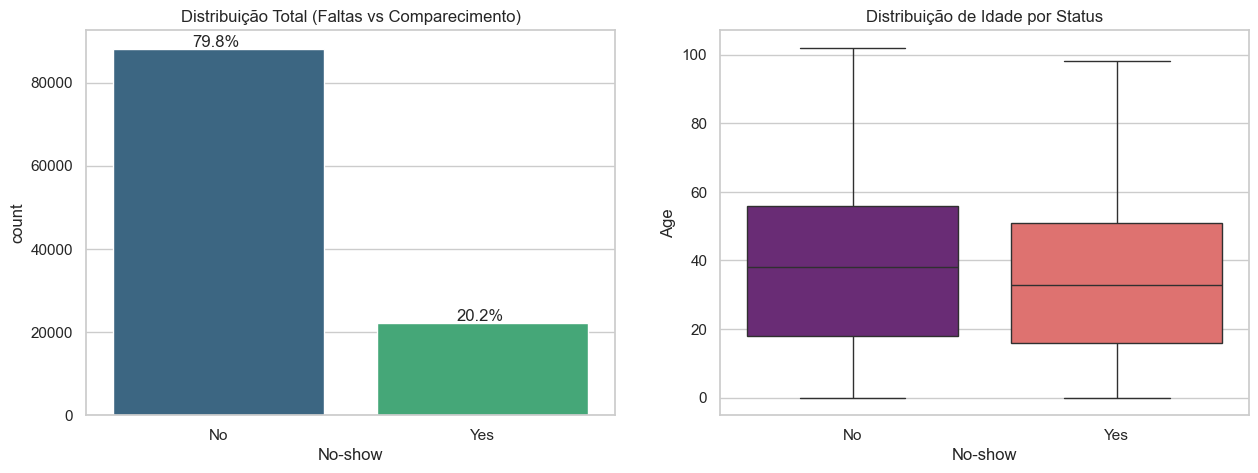

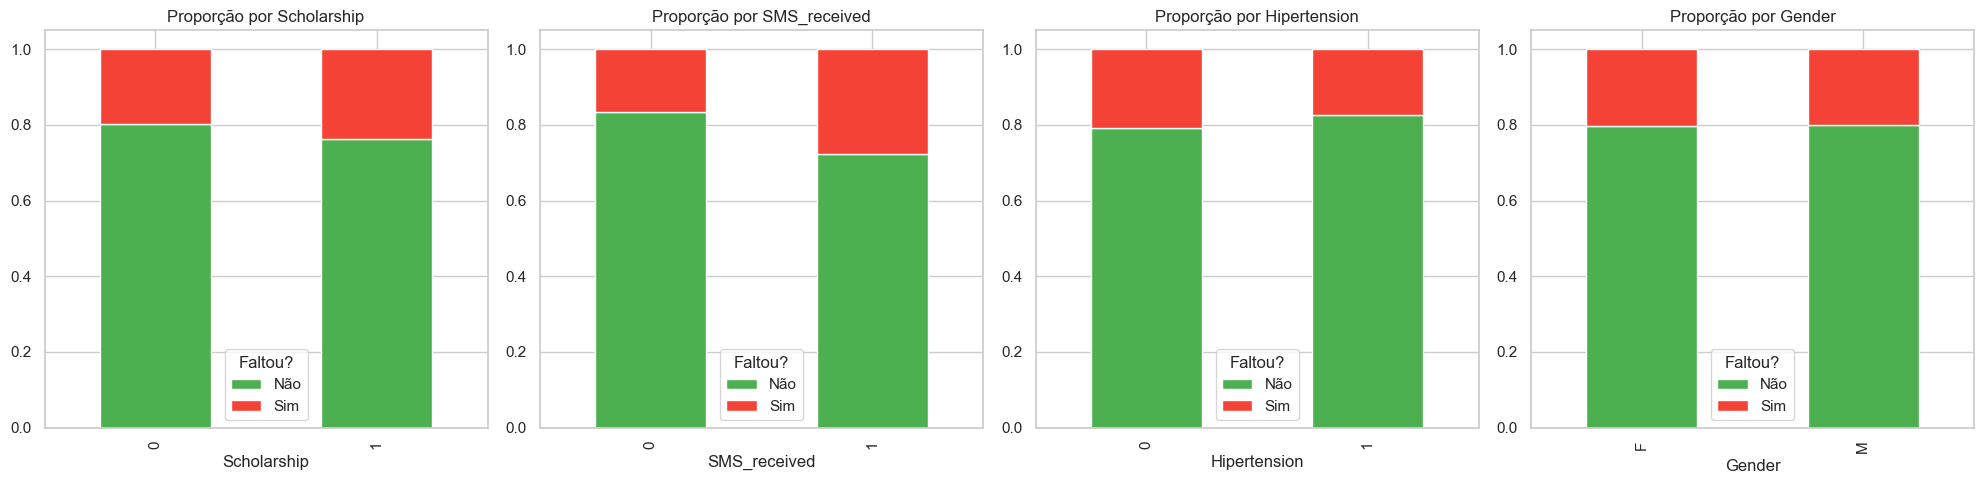

In [84]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def analise_exploratoria_completa(df):
    sns.set_theme(style="whitegrid")
    
    # --- VISUALIZAÇÃO 1: DISTRIBUIÇÃO ALVO E IDADE (SEU CÓDIGO) ---
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Proporção da Variável Alvo
    ax = sns.countplot(x='No-show', data=df, hue='No-show', palette='viridis', legend=False, ax=axes[0])
    axes[0].set_title('Distribuição Total (Faltas vs Comparecimento)')
    total = len(df)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        axes[0].annotate(percentage, (p.get_x() + 0.3, p.get_height() + 500))

    # Idade por No-show
    sns.boxplot(x='No-show', y='Age', data=df, hue='No-show', palette='magma', legend=False, ax=axes[1])
    axes[1].set_title('Distribuição de Idade por Status')
    plt.show()

    # --- VISUALIZAÇÃO 2: VARIÁVEIS CATEGÓRICAS (SEU CÓDIGO MELHORADO) ---
    cols = ['Scholarship', 'SMS_received', 'Hipertension', 'Gender']
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    for i, col in enumerate(cols):
        tab = pd.crosstab(df[col], df['No-show'], normalize='index')
        tab.plot(kind='bar', stacked=True, ax=axes[i], color=['#4CAF50', '#F44336'])
        axes[i].set_title(f'Proporção por {col}')
        axes[i].legend(title='Faltou?', labels=['Não', 'Sim'])
    plt.tight_layout()
    plt.show()

analise_exploratoria_completa(df_limpo)

### Padrões Identificados:

* **Desbalanceamento:** 79,8% compareceram e 20,2% faltaram. A acurácia simples não é métrica suficiente — F1-Score e Matriz de Confusão serão necessários.
* **Idade:** Pacientes que faltam têm mediana de idade menor. Pacientes mais jovens são mais propensos ao "No-show".
* **SMS_received:** O grupo que recebeu SMS falta mais, pois o SMS é enviado para consultas agendadas com maior antecedência — que já são naturalmente mais sujeitas ao esquecimento.
* **Hipertensão:** Pacientes hipertensos comparecem mais, comportamento esperado em portadores de doenças crônicas que dependem de acompanhamento contínuo.
* **Scholarship:** Beneficiários de auxílio social faltam proporcionalmente mais, sugerindo barreiras de deslocamento ou rotina que dificultam o comparecimento.
* **Gênero:** Sem diferença relevante entre homens e mulheres.

**Conclusão:** `Age`, `SMS_received` e `Hipertension` apresentam as distinções mais acentuadas e são os principais candidatos a preditores.